# UPI Guardian - data exploration
A look at every dataset the models use. All datasets are committed under `data/raw/` (see `docs/04_DATASET.md`).

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "backend")); sys.path.insert(0, str(ROOT / "ml"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
RAW = ROOT / "data" / "raw"
print("project root:", ROOT)

project root: D:\abstracts\Madhav\CSDS\B\CSDS-B-B4\8.ProjectCode


## 1. Digital Payment Fraud Detection Benchmark (M1)
400,000 transactions over 2023 with a strict time split and drift after month 6.

In [2]:
bench = pd.concat([pd.read_csv(RAW/"payment_fraud_benchmark"/f, parse_dates=["transaction_time"]) for f in ("transactions_train.csv","transactions_test.csv")])
print(bench.shape); bench.head(3)

(400000, 21)


,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,payment_channel,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,2023-01-01 00:02:00.328105993,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,wallet,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,2023-01-01 00:02:26.339769237,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,bank_transfer,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,2023-01-01 00:06:54.145825305,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,card,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647


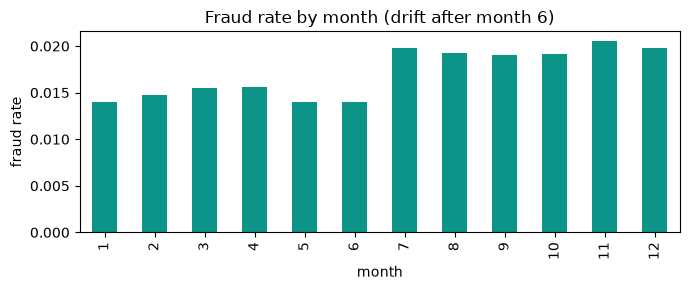

In [3]:
monthly = bench.groupby(bench.transaction_time.dt.month).is_fraud.mean()
ax = monthly.plot(kind="bar", color="#0d9488", figsize=(7,3), title="Fraud rate by month (drift after month 6)")
ax.set_xlabel("month"); ax.set_ylabel("fraud rate"); plt.tight_layout(); plt.show()

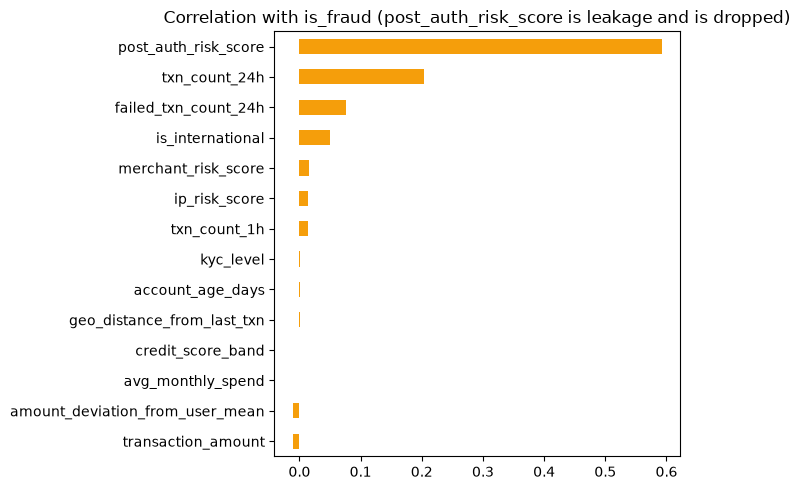

In [4]:
corr = bench.drop(columns=["transaction_id","customer_id","merchant_id"]).select_dtypes("number").corr()["is_fraud"].drop("is_fraud").sort_values()
corr.plot(kind="barh", color="#f59e0b", figsize=(7,5), title="Correlation with is_fraud (post_auth_risk_score is leakage and is dropped)"); plt.tight_layout(); plt.show()

## 2. UPI Transactions 2024 (behaviour profiles)
Its `fraud_flag` turns out not to be learnable, so it is used for amounts and time-of-day profiles.

(250000, 17) fraud_flag rate 0.0019


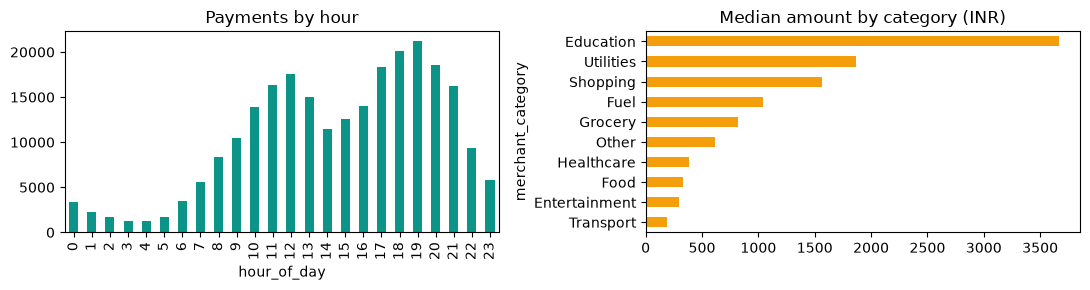

In [5]:
upi = pd.read_csv(RAW/"upi_transactions_2024"/"upi_transactions_2024.csv", parse_dates=["timestamp"])
print(upi.shape, "fraud_flag rate", round(upi.fraud_flag.mean(), 4))
fig, ax = plt.subplots(1, 2, figsize=(11,3))
upi.hour_of_day.value_counts().sort_index().plot(kind="bar", ax=ax[0], color="#0d9488", title="Payments by hour")
upi.groupby("merchant_category")["amount (INR)"].median().sort_values().plot(kind="barh", ax=ax[1], color="#f59e0b", title="Median amount by category (INR)")
plt.tight_layout(); plt.show()

In [6]:
for c in ["transaction type", "merchant_category", "device_type"]:
    print(c, upi.groupby(c).fraud_flag.mean().round(4).to_dict())

transaction type {'Bill Payment': 0.0021, 'P2M': 0.0019, 'P2P': 0.0018, 'Recharge': 0.0024}
merchant_category {'Education': 0.0021, 'Entertainment': 0.002, 'Food': 0.0019, 'Fuel': 0.0019, 'Grocery': 0.0019, 'Healthcare': 0.0017, 'Other': 0.002, 'Shopping': 0.0021, 'Transport': 0.0021, 'Utilities': 0.0015}
device_type {'Android': 0.0019, 'Web': 0.0021, 'iOS': 0.0018}


## 3. SMS Spam Collection + Indian UPI-scam SMS set (M2)

In [7]:
uci = pd.read_csv(RAW/"sms_spam_collection"/"spam.csv", encoding="latin-1")[["v1","v2"]]
ind = pd.read_csv(RAW/"upi_scam_sms"/"upi_scam_sms.csv")
print("UCI:", uci.v1.value_counts().to_dict(), "| Indian set:", ind.label.value_counts().to_dict())
pd.crosstab(ind.category, ind.language)

UCI: {'ham': 4825, 'spam': 747} | Indian set: {1: 527, 0: 288}


language,en,hi,te
category,,,
bank_credit,12,12,12
bank_debit,12,12,12
bill_disconnection,12,12,12
bill_reminder,12,12,12
collect_note,10,3,3
collect_request,24,18,18
courier_customs,12,12,12
delivery,12,12,12
impersonation,12,12,12


In [8]:
ind.groupby(["language","script"]).size().unstack(fill_value=0)

script,latin,native
language,,
en,0,275
hi,123,147
te,123,147


## 4. Scenario simulator sample (M3)
A 5,000-row sample of the simulated UPI year (`data/sample/upi_scenarios_sample.csv`, scams over-sampled for readability).

In [9]:
sim = pd.read_csv(ROOT/"data"/"sample"/"upi_scenarios_sample.csv")
print(sim.shape); print(sim.scam_type.value_counts().to_dict())
sim.groupby("label")[["is_new_payee","payee_account_age_days","payee_reports","sms_scam_prob","is_night","amount_to_median"]].mean().round(3)

(5000, 34)
{'none': 4040, 'job_task': 237, 'refund_scam': 132, 'kyc_fraud': 132, 'lottery_prize': 84, 'impersonation': 80, 'investment': 69, 'qr_scam': 56, 'loan_fee': 49, 'bill_disconnection': 38, 'wrong_transfer': 31, 'account_takeover': 29, 'courier_customs': 23}


,is_new_payee,payee_account_age_days,payee_reports,sms_scam_prob,is_night,amount_to_median
label,,,,,,
0,0.164,1532.255,0.000,0.000,0.102,1.883
1,0.574,397.012,0.073,0.119,0.205,13.068
